In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv("C:/Users/Administrator/Downloads/heart.csv")

In [3]:
df.shape

(1025, 14)

In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [6]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [7]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(723)

In [10]:
df = df.drop_duplicates()

In [12]:
df["target"].value_counts()

target
1    164
0    138
Name: count, dtype: int64

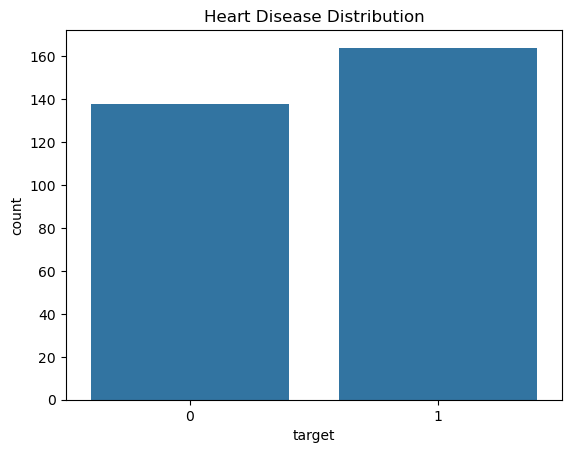

In [13]:
sns.countplot(x="target", data=df)

plt.title("Heart Disease Distribution")

plt.show()

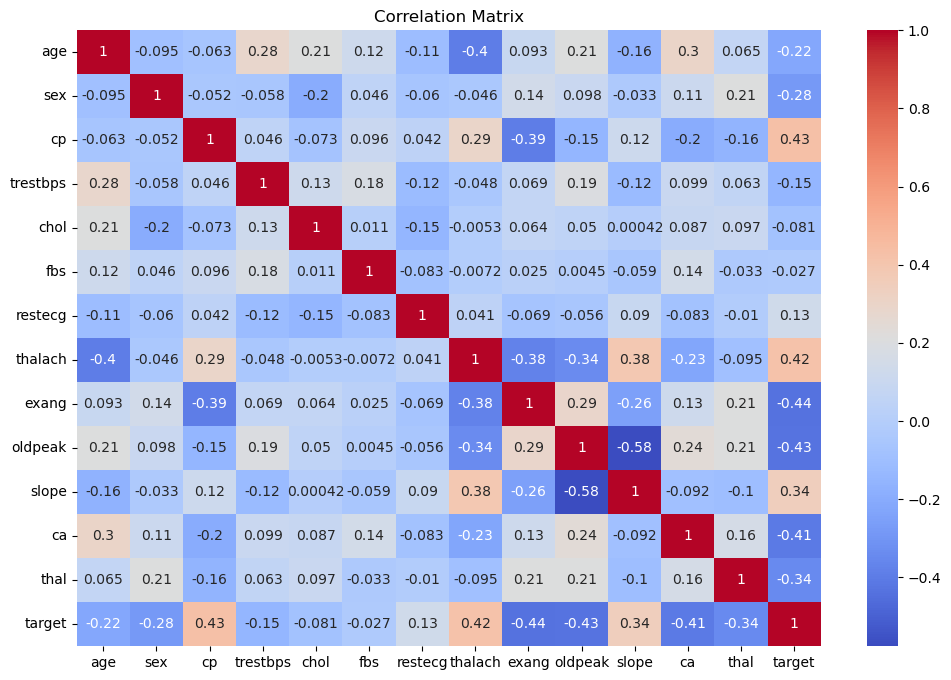

In [14]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

In [36]:
x = df.drop("target",axis=1)
y = df["target"]

In [37]:
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2,random_state=42)

In [38]:
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [39]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [40]:
lr_pred = model.predict(x_test)
print(lr_pred)

[1 1 0 1 1 0 0 1 1 0 1 0 1 1 1 0 0 1 0 1 1 1 0 1 0 0 1 1 0 1 1 1 1 1 1 1 1
 1 0 0 0 0 0 1 0 1 1 0 1 1 1 0 0 1 1 0 1 1 0 0 1]


In [41]:
lr_accuracy = accuracy_score(y_test,lr_pred)
print("LR_Accuracy: ",lr_accuracy)

LR_Accuracy:  0.7704918032786885


In [42]:
dt_model = DecisionTreeClassifier()
dt_model.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [43]:
dt_pred = dt_model.predict(x_test)
print(dt_pred)

[1 1 0 0 1 0 1 1 0 0 1 0 1 0 1 0 0 1 0 1 1 0 0 1 0 0 1 1 0 1 1 0 1 1 1 1 0
 1 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 1 1 0 0 1 0 0 0]


In [44]:
dt_accuracy = accuracy_score(y_test,dt_pred)
print("DT_Accuracy: ",dt_accuracy)

DT_Accuracy:  0.7540983606557377


In [45]:
rf_model = RandomForestClassifier()
rf_model.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [46]:
rf_pred = rf_model.predict(x_test)
print(rf_pred)

[1 1 0 0 1 0 0 1 1 1 1 0 1 1 1 0 0 1 0 1 1 0 0 1 0 0 1 1 0 1 1 1 1 1 1 1 0
 1 0 0 0 0 1 0 0 0 1 0 1 1 0 0 0 1 1 0 1 1 0 0 1]


In [47]:
rf_accuracy = accuracy_score(y_test,rf_pred)
print("RF Accuracy: ",rf_accuracy)

RF Accuracy:  0.8360655737704918


In [53]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [54]:
knn_pred = knn_model.predict(x_test)
print(knn_pred)


[1 1 0 0 0 0 0 1 1 1 1 0 1 1 1 0 0 1 0 1 1 1 0 1 0 0 1 1 0 1 1 1 1 1 1 0 0
 1 0 0 0 1 1 0 0 0 1 0 1 1 1 0 0 1 1 0 0 1 0 0 1]


In [55]:
knn_accuracy = accuracy_score(y_test,knn_pred)
print("KNN_Accuarcy: ",knn_accuracy)

KNN_Accuarcy:  0.7377049180327869


In [56]:
print("Logistic Regression :", lr_accuracy)
print("Decision Tree       :", dt_accuracy)
print("Random Forest       :", rf_accuracy)
print("KNN                 :", knn_accuracy)

Logistic Regression : 0.7704918032786885
Decision Tree       : 0.7540983606557377
Random Forest       : 0.8360655737704918
KNN                 : 0.7377049180327869


In [57]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.89      0.78      0.83        32
           1       0.79      0.90      0.84        29

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



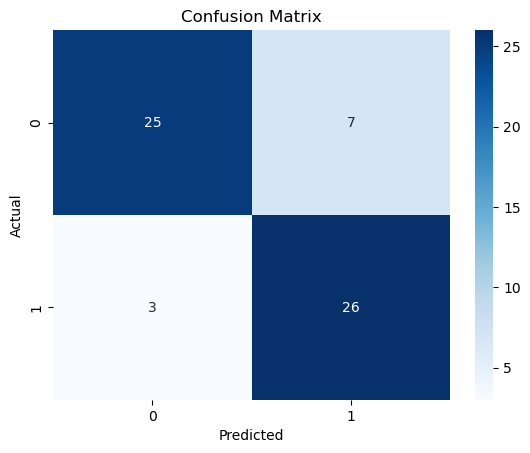

In [58]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [61]:
sample = x.iloc[[0]]

sample = sc.transform(sample)

prediction = rf_model.predict(sample)

if prediction[0] == 1:
    print("Heart Disease Detected")
else:
    print("No Heart Disease")

No Heart Disease
